In [205]:
import os
from pathlib import Path
import pickle
from matplotlib import pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from glmhmm import *
from plotting_style import *

In [206]:
# Magics
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [207]:
# Plotting style
style_path = os.path.expanduser('~/PycharmProjects/alexis_style.mplstyle')
plt.style.use(style_path)
%config InlineBackend.figure_format = 'svg'
# %config InlineBackend.figure_format = 'retina'
sns.set_style('ticks')
sns.set_context('notebook')

In [208]:
# Load results
path = Path.home() / 'PycharmProjects' / 'glmhmm' / 'results.pkl'
with open(path, 'rb') as f:
    results = pickle.load(f)

# Unpack results
all_animals = results['all_animals']
experiment = results['experiment']
fit_ll = results['fit_ll']
weights = results['weights']
trans_mat = results['trans_mat']
posterior_probs = results['posterior_probs']
log_likelihood = results['log_likelihood']
# remap_indices = results['remap_indices']
drug = results['drug']
interpret = results['interpret']

data = results_2_df(all_animals, experiment, weights)

# Mean groups 2-4

Covariate 0: t=8.707, p=0.0000
Covariate 1: t=-3.175, p=0.0041
Covariate 2: t=-3.480, p=0.0019


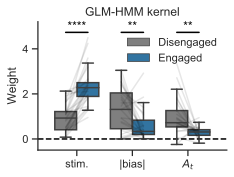

In [209]:
figsize = fig_size(n_cols=2)
mask = data.Experiment.isin(['2AFC_2', '2AFC_3', '2AFC_4'])
plot_paired_boxplot_GLMHMM_kernel(data[mask], drug=False, figsize=figsize, loc='upper right',  bbox_to_anchor=(1, 0.95))

array([[0.93832208, 0.06167792],
       [0.03097771, 0.96902229]])

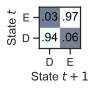

In [210]:
figsize = (fig_size(n_cols=2)[1]/2, fig_size(n_cols=2)[1]/2)
plot_trans_mat(trans_mat[:-10], figsize=figsize)

State 0 occupancy: 0.29
State 1 occupancy: 0.71


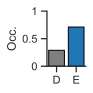

In [211]:
figsize = (fig_size(n_cols=2)[1]/2, fig_size(n_cols=2)[1]/2)
plot_occupancy(posterior_probs[:-10], figsize=figsize)

Log likelihood (normalized by number of trials): -0.66 ± 0.09 (mean ± SD across subjects)


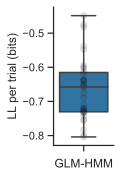

In [212]:
figsize = (fig_size(n_cols=2)[0]/2, fig_size(n_cols=2)[1])
plot_log_likelihood(log_likelihood, posterior_probs, to_bits=True, figsize=figsize)

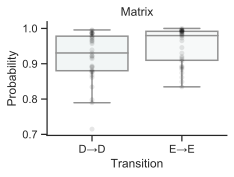

In [213]:
figsize = fig_size(n_cols=2)
plot_trans_mat_box_plots(trans_mat, figsize=figsize)

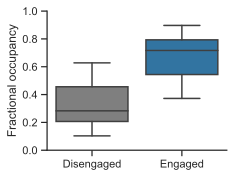

In [214]:
figsize = fig_size(n_cols=2)
_ = plot_occupancy_boxplot(posterior_probs, figsize=figsize)

# Group 2

Mice: ['325' '326' '327' '329' '330' '332' '333' '335' '337']
Covariate 0: t=8.040, p=0.0000
Covariate 1: t=-2.204, p=0.0586
Covariate 2: t=-1.546, p=0.1606


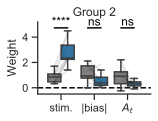

In [215]:
experiment = '2AFC_2'
figsize = fig_size(n_cols=3)
mask = data.Experiment == experiment
print(f'Mice: {data[mask].Animal.unique()}')
title = 'Group ' + experiment[-1]
ax = plot_paired_boxplot_GLMHMM_kernel(data[data.Experiment==experiment], title=title, figsize=figsize)
ax.legend_.remove()

# Group 3

Mice: ['419' '420' '422' '616' '617' '619' '623']
Covariate 0: t=3.980, p=0.0073
Covariate 1: t=-1.181, p=0.2824
Covariate 2: t=-2.326, p=0.0590


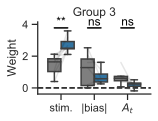

In [216]:
experiment = '2AFC_3'
figsize = fig_size(n_cols=3)
mask = data.Experiment == experiment
print(f'Mice: {data[mask].Animal.unique()}')
title = 'Group ' + experiment[-1]
ax = plot_paired_boxplot_GLMHMM_kernel(data[data.Experiment==experiment], title=title, figsize=figsize)
ax.legend_.remove()

# Group 4

Mice: ['561' '807' '820' '821' '873' '875' '907' '909' '911']
Covariate 0: t=5.485, p=0.0006
Covariate 1: t=-2.306, p=0.0500
Covariate 2: t=-2.534, p=0.0351


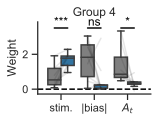

In [217]:
experiment = '2AFC_4'
figsize = fig_size(n_cols=3)
mask = data.Experiment == experiment
print(f'Mice: {data[mask].Animal.unique()}')
title = 'Group ' + experiment[-1]
ax = plot_paired_boxplot_GLMHMM_kernel(data[data.Experiment==experiment], title=title, figsize=figsize)
ax.legend_.remove()

# Group 6
Drug

## Rest
No injection (no saline nor drug)

Mice: ['014' '016' '017' '018' '019' '020' '022' '023' '024' '025']
Covariate 0: t=5.223, p=0.0005
Covariate 1: t=-0.189, p=0.8543
Covariate 2: t=-0.923, p=0.3800


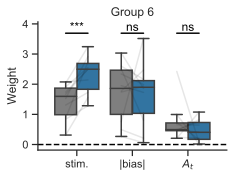

In [218]:
experiment = '2AFC_6'
figsize = fig_size(n_cols=2)
mask = data.Experiment == experiment
print(f'Mice: {data[mask].Animal.unique()}')
title = 'Group ' + experiment[-1]
ax = plot_paired_boxplot_GLMHMM_kernel(data[data.Experiment==experiment], title=title, figsize=figsize)
ax.legend_.remove()

array([[0.88030467, 0.11969533],
       [0.09649699, 0.90350301]])

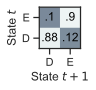

In [219]:
figsize = (fig_size(n_cols=2)[1]/2, fig_size(n_cols=2)[1]/2)
plot_trans_mat(trans_mat[-10:], figsize=figsize)

State 0 occupancy: 0.41
State 1 occupancy: 0.59


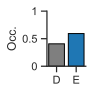

In [220]:
figsize = (fig_size(n_cols=2)[1]/2, fig_size(n_cols=2)[1]/2)
plot_occupancy(posterior_probs[-10:], figsize=figsize)

([<matplotlib.axis.XTick at 0x1ddd9418e88>,
 <a list of 2 Text xticklabel objects>)

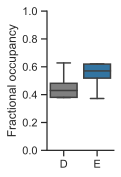

In [221]:
figsize = fig_size(n_cols=2)
figsize = (figsize[0]/2, figsize[1])
_ = plot_occupancy_boxplot(posterior_probs[-10:], figsize=figsize)
plt.xticks([0, 1], ['D', 'E'])

## Saline

In [222]:
# Load results
path = Path.home() / 'PycharmProjects' / 'glmhmm' / 'results_saline.pkl'
with open(path, 'rb') as f:
    results = pickle.load(f)

# Unpack results
all_animals = results['all_animals']
experiment = results['experiment']
fit_ll = results['fit_ll']
weights_saline = results['weights']
trans_mat_saline = results['trans_mat']
posterior_probs_saline = results['posterior_probs']
log_likelihood = results['log_likelihood']
# remap_indices = results['remap_indices']
# interpret = results['interpret']
data_saline = results_2_df(all_animals, experiment, weights_saline)

In [223]:
# Print the number of sessions in results_drug.posterior_probs
for session_probs in results['posterior_probs']:
    print(f' N sessions per subject: {len(session_probs)}')

 N sessions per subject: 7
 N sessions per subject: 9
 N sessions per subject: 10
 N sessions per subject: 5
 N sessions per subject: 4
 N sessions per subject: 11
 N sessions per subject: 10
 N sessions per subject: 9
 N sessions per subject: 9
 N sessions per subject: 9


Covariate 0: t=3.965, p=0.0033
Covariate 1: t=-0.064, p=0.9501
Covariate 2: t=-1.773, p=0.1100


Text(0.5, 1, 'Saline')

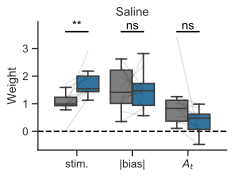

In [224]:
figsize = fig_size(n_cols=2)
ax = plot_paired_boxplot_GLMHMM_kernel(data_saline, figsize=figsize)
ax.legend_.remove()
plt.title('Saline')

array([[0.89050467, 0.10949533],
       [0.09009037, 0.90990963]])

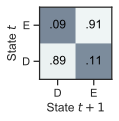

In [225]:
# figsize = (fig_size(n_cols=2)[1]/2, fig_size(n_cols=2)[1]/2)
figsize = fig_size(n_cols=2)
figsize = (figsize[0]/2, figsize[0]/2)
plot_trans_mat(trans_mat_saline, figsize=figsize)

State 0 occupancy: 0.42
State 1 occupancy: 0.58


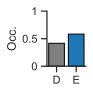

In [226]:
figsize = (fig_size(n_cols=2)[1]/2, fig_size(n_cols=2)[1]/2)
plot_occupancy(posterior_probs_saline, figsize=figsize)

([<matplotlib.axis.XTick at 0x1ddd9644808>,
 <a list of 2 Text xticklabel objects>)

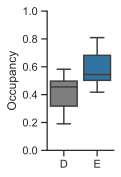

In [227]:
figsize = fig_size(n_cols=2)
figsize = (figsize[0]/2, figsize[1])
df_occ_saline = plot_occupancy_boxplot(posterior_probs_saline, figsize=figsize)
plt.ylabel('Occupancy')
plt.xticks([0, 1], ['D', 'E'])

## Drug

In [228]:
# Load results
path = Path.home() / 'PycharmProjects' / 'glmhmm' / 'results_drug.pkl'
with open(path, 'rb') as f:
    results = pickle.load(f)

# Unpack results
all_animals = results['all_animals']
experiment = results['experiment']
fit_ll = results['fit_ll']
weights_drug = results['weights']
trans_mat_drug = results['trans_mat']
posterior_probs_drug = results['posterior_probs']
log_likelihood = results['log_likelihood']
# remap_indices = results['remap_indices']
# interpret = results['interpret']
data_drug = results_2_df(all_animals, experiment, weights_drug)

In [229]:
# Print the number of sessions in results_drug.posterior_probs
for session_probs in results['posterior_probs']:
    print(f' N sessions per subject: {len(session_probs)}')

 N sessions per subject: 7
 N sessions per subject: 9
 N sessions per subject: 10
 N sessions per subject: 5
 N sessions per subject: 4
 N sessions per subject: 11
 N sessions per subject: 9
 N sessions per subject: 9
 N sessions per subject: 9
 N sessions per subject: 9


Covariate 0: t=7.850, p=0.0000
Covariate 1: t=0.415, p=0.6879
Covariate 2: t=-2.594, p=0.0290


Text(0.5, 1, 'Drug')

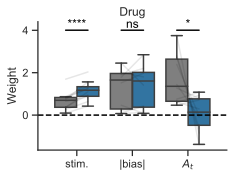

In [230]:
figsize = fig_size(n_cols=2)
ax = plot_paired_boxplot_GLMHMM_kernel(data_drug, figsize=figsize, palette={0: 'tab:gray', 1: 'tab:blue'}, loc='lower left', bbox_to_anchor=(0, -0.05))
ax.legend_.remove()
plt.title('Drug')

array([[0.91848583, 0.08151417],
       [0.07557074, 0.92442926]])

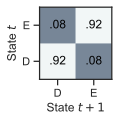

In [231]:
# figsize = (fig_size(n_cols=2)[1]/2, fig_size(n_cols=2)[1]/2)
figsize = fig_size(n_cols=2)
figsize = (figsize[0]/2, figsize[0]/2)
plot_trans_mat(trans_mat_drug, figsize=figsize)

State 0 occupancy: 0.50
State 1 occupancy: 0.50


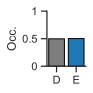

In [232]:
figsize = (fig_size(n_cols=2)[1]/2, fig_size(n_cols=2)[1]/2)
plot_occupancy(posterior_probs_drug, figsize=figsize, color=['tab:gray', 'tab:blue'])

([<matplotlib.axis.XTick at 0x1ddd98972c8>,
 <a list of 2 Text xticklabel objects>)

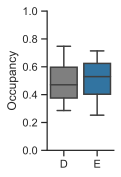

In [233]:
figsize = fig_size(n_cols=2)
figsize = (figsize[0]/2, figsize[1])
df_occ_drug = plot_occupancy_boxplot(posterior_probs_drug, figsize=figsize, palette=['tab:gray', 'tab:blue'])
plt.ylabel('Occupancy')
plt.xticks([0, 1], ['D', 'E'])

## Combine data from states to compare saline vs drug

In [234]:
# Combine saline and drug data DataFrames
data_saline['Drug'] = 0
data_drug['Drug'] = 1
data = pd.concat([data_saline, data_drug], ignore_index=True)

Covariate 0: t=6.254, p=0.0000
Covariate 1: t=0.147, p=0.8850
Covariate 2: t=-3.055, p=0.0065


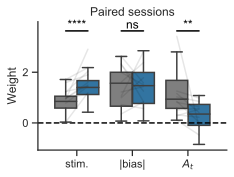

In [235]:
# Combine saline and drug sessions together
figsize = fig_size(n_cols=2)
ax = plot_paired_boxplot_GLMHMM_kernel(data, drug=False, figsize=figsize, loc='upper left', bbox_to_anchor=(0, 0.995))
plt.title('Paired sessions')
ax.legend_.remove()

t=-1.663, p=0.1307
t=1.663, p=0.1307


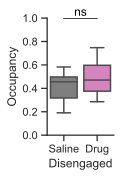

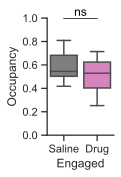

In [236]:
# Combine occupancy dataframes by state. So one df_engaged and one df_disengaged
df_occ_saline['Drug'] = 0
df_occ_drug['Drug'] = 1
df_occ = pd.concat([df_occ_saline, df_occ_drug], ignore_index=True)
figsize = fig_size(n_cols=2)
figsize = (figsize[0]/2, figsize[1])

# Disengaged
plt.figure(figsize=figsize, constrained_layout=True)
sns.boxplot(data=df_occ, x='Drug', y='Disengaged', palette=['tab:gray','tab:pink'], showfliers=False)
plt.xticks([0,1], ['Saline','Drug'])
plt.ylim(0, 1)
plt.xlabel('Disengaged')
plt.ylabel('Occupancy')
sns.despine()
p_saline = df_occ[df_occ.Drug==0]['Disengaged']
p_drug = df_occ[df_occ.Drug==1]['Disengaged']
t_stat, p_val = ttest_rel(p_saline, p_drug)
print(f't={t_stat:.3f}, p={p_val:.4f}')
add_star_between(p_val)

# Engaged
plt.figure(figsize=figsize, constrained_layout=True)
sns.boxplot(data=df_occ, x='Drug', y='Engaged', palette=['tab:gray','tab:pink'], showfliers=False)
plt.xticks([0,1], ['Saline','Drug'])
plt.ylim(0, 1)
plt.xlabel('Engaged')
plt.ylabel('Occupancy')
sns.despine()
p_saline = df_occ[df_occ.Drug==0]['Engaged']
p_drug = df_occ[df_occ.Drug==1]['Engaged']
t_stat, p_val = ttest_rel(p_saline, p_drug)
print(f't={t_stat:.3f}, p={p_val:.4f}')
add_star_between(p_val)

Mean Disengaged: 0.457 ± 0.032
Mean Engaged: 0.543 ± 0.032


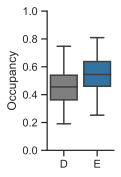

In [237]:
df_occ_melt = df_occ.drop(columns='Drug').melt(id_vars='Subject', var_name='State', value_name='Occupancy')
figsize = fig_size(n_cols=2)
figsize = (figsize[0]/2, figsize[1])
plt.figure(figsize=figsize, constrained_layout=True)
sns.boxplot(data=df_occ_melt, x='State', y='Occupancy', palette=['tab:gray','tab:blue'], showfliers=False)
plt.xticks([0,1], ['D','E'])
plt.ylim(0, 1)
plt.xlabel('')
plt.ylabel('Occupancy')
sns.despine()
p_disengaged = df_occ.Disengaged
print(f'Mean Disengaged: {p_disengaged.mean():.3f} ± {p_disengaged.sem():.3f}')
p_engaged = df_occ.Engaged
print(f'Mean Engaged: {p_engaged.mean():.3f} ± {p_engaged.sem():.3f}')

array([[0.90449525, 0.09550475],
       [0.08283056, 0.91716944]])

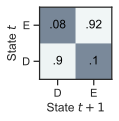

In [238]:
trans_mat_saline = plot_trans_mat(trans_mat_saline)
plt.close()
trans_mat_drug = plot_trans_mat(trans_mat_drug)
plt.close()
trans_mat = np.mean([trans_mat_saline, trans_mat_drug], axis=0)
figsize = fig_size(n_cols=2)
figsize = (figsize[0]/2, figsize[0]/2)
plot_trans_mat(trans_mat, figsize=figsize)

## Disengaged

Covariate 0: t=-2.645, p=0.0267
Covariate 1: t=-0.764, p=0.4642
Covariate 2: t=1.868, p=0.0946


Text(0.5, 1, 'Disengaged')

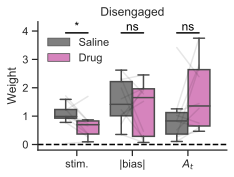

In [239]:
figsize = fig_size(n_cols=2)
ax = plot_paired_boxplot_GLMHMM_kernel(data[data.Label=='Disengaged'], drug=True, figsize=figsize, loc='upper left', bbox_to_anchor=(0, 0.95))
plt.title('Disengaged')

## Engaged

Covariate 0: t=-3.498, p=0.0067
Covariate 1: t=-0.611, p=0.5560
Covariate 2: t=-0.887, p=0.3981


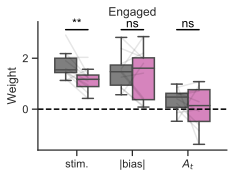

In [240]:
figsize = fig_size(n_cols=2)
ax = plot_paired_boxplot_GLMHMM_kernel(data[data.Label=='Engaged'], drug=True, figsize=figsize)
plt.title('Engaged')
ax.get_legend().remove()

# Save all notebook's figures

In [243]:
# # Whole notebook outputs (no input or prompt, only Markdown and figures)
# # As HTML
# !jupyter nbconvert notebook.ipynb --to html --no-input --no-prompt
# # As PDF
# !jupyter nbconvert notebook.ipynb --to pdf --no-input --no-prompt
#
# Export all figures
save_notebook_files(notebook_path='notebook_full_model.ipynb')

Saved 28 images to notebook_full_model_files/
